# BESS Project Commercial Viability — Stochastic Cash Flow Model

**Version: v8**

| Version | Change |
|---|---|
| v1 | Initial Monte Carlo engine: constant (mean/std) revenue, NPV/IRR distributions, CDFs |
| v2 | Replaced constant revenue with a declining calendar-year curve (anchor points, now → 2050) |
| v3 | Switched percentile labelling to **exceedance-probability convention** (P5 = high/optimistic value, P95 = low/conservative value — i.e. your P5 ⇄ statistical P95, your P95 ⇄ statistical P5) |
| v4 | Removed "max operational period" as a stochastic input. SoH cut-off is now **deterministic (60%)**; operating life is an **output** of the simulation — each run continues until simulated SoH reaches the cut-off |
| v5 | CDF replaced with **exceedance curve** (x-axis: value, y-axis: probability of exceeding that value — P95 left/conservative, P05 right/optimistic); P95/P75/P50/P25/P05 markers added to plot; summary table reordered P95 → P05 |
| v6 | Revenue model reworked: driven by **daily spread (EUR/MWh) × effective MWh × cycles/day × 365**. Cycles/day drawn stochastically each year (mean=2, 95% CI [1.5, 2.2], hard cap 2.2). Cycles now drive both revenue and SoH degradation simultaneously. Spread anchors replace EUR/MW/yr revenue anchors. `max_cycles_day` removed as a separate stochastic input. |
| v7 | Added **auto-install cell** at top of notebook — `numpy_financial` and `scipy` are installed automatically if missing, so the notebook runs without any manual pip commands |
| v8 | **Consolidated all input definitions into one cell** (was 4 separate cells) — eliminates `NameError` from running cells out of order; visualisations are separate optional cells below |


Monte Carlo simulation of a standalone BESS project. Deterministic inputs (size, discount rate,
number of simulations) are fixed; all other inputs are drawn from **truncated normal distributions**
(mean/std as supplied, truncated so values can't go negative or outside physical bounds).

**Engine logic per simulated project:**
1. Draw project-level stochastic parameters once per simulation (degradation/cycle, CAPEX, OPEX).
2. Simulate year by year:
   - Draw that year's **cycles/day** from a truncated normal (mean=2, hard cap=2.2) — year-to-year dispatch variability.
   - Draw that year's **daily spread** (EUR/MWh) from the declining spread curve.
   - Compute revenue: `spread × MWh × (SoH/100) × cycles_per_day × 365` — SoH scaling means degraded capacity earns less.
   - Degrade SoH: `annual_cycles × deg_per_cycle` — more cycling = faster degradation.
   - Subtract OPEX.
3. The project retires once SoH hits the deterministic cut-off (60%).
4. Discount the cash flow stream → NPV; solve for IRR.
5. Repeat for `N_SIMULATIONS` draws → distribution of outcomes.

> **All numeric inputs below are placeholder example values** (illustrative, not calibrated to a real site).
> Replace them in the **Inputs** cell with your own assumptions before relying on the output.

In [1]:
# Auto-install any missing dependencies
import subprocess, sys

def ensure(pkg, import_name=None):
    import_name = import_name or pkg
    try:
        __import__(import_name)
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
        print(f"{pkg} installed.")

ensure("numpy_financial")
ensure("scipy")
print("All dependencies ready.")

Installing numpy_financial...
numpy_financial installed.
All dependencies ready.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm
import numpy_financial as npf
import pandas as pd

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Inputs

> ⚡ **Run order matters.** Execute cells top-to-bottom, or use **Kernel → Restart & Run All Cells**.
> All variable definitions live in the single code cell below — run it once and everything downstream
> will work.

### What lives where

| Group | Drawn when | Parameters |
|---|---|---|
| Deterministic | Fixed constants | MW, MWh, discount rate, SoH cut-off, # simulations |
| Per-simulation | Once per Monte Carlo run | Degradation/cycle, CAPEX, OPEX |
| Per-year | Each year inside the loop | Cycles/day, daily spread (from declining curve) |

**Revenue formula:**
```
revenue_year = spread (EUR/MWh) × MWh × (SoH/100) × cycles_per_day × 365
```

In [6]:
import numpy as np  # re-import guard (safe to run multiple times)
from scipy.stats import truncnorm

# ── Helper ───────────────────────────────────────────────────────────────────
def sample_truncnorm(mean, std, low, high, size, rng):
    """Truncated-normal draw. Returns array of `size` samples in [low, high]."""
    if std <= 0:
        return np.full(size, mean)
    a, b = (low - mean) / std, (high - mean) / std
    return truncnorm.rvs(a, b, loc=mean, scale=std, size=size, random_state=rng)

# ── 1a. Deterministic inputs ──────────────────────────────────────────────────
MW               = 20.0    # Power rating, MW
MWH              = 40.0    # Energy capacity, MWh (2h duration)
DISCOUNT_RATE    = 0.08    # Annual WACC / discount factor
N_SIMULATIONS    = 10_000  # Monte Carlo draws
RANDOM_SEED      = 42      # Reproducibility (set None for random)
SOH_CUTOFF_PCT   = 60.0    # Retire project when SoH falls to this level (%)
PROJECT_START_YEAR = 2027  # Commissioning / COD year

rng = np.random.default_rng(RANDOM_SEED)

# ── 1b. Per-simulation stochastic inputs ──────────────────────────────────────
STOCHASTIC_INPUTS = {
    #                          mean      std     low      high
    "deg_per_cycle_pct": dict(mean=0.005,   std=0.001, low=0,      high=1),
    "capex_eur_per_mwh": dict(mean=300_000, std=30_000, low=50_000, high=np.inf),
    "opex_eur_per_mw":   dict(mean=12_000,  std=2_000,  low=0,      high=np.inf),
}

# ── 1c. Cycles per day — drawn each year (dispatch variability) ───────────────
# 95% CI [1.5, 2.2], mean = 2.  CI is asymmetric so σ is derived from the
# lower bound: (2.0 - 1.5) / 1.96 ≈ 0.255.  Hard cap at 2.2 via truncation.
CYCLES_MEAN  = 1.8
CYCLES_STD   = 0.255   # (mean - 1.5) / 1.96
CYCLES_LOW   = 0.0
CYCLES_HIGH  = 2.2

# ── 1d. Daily spread curve — drawn each year (EUR/MWh, declining to 2050) ────
# Edit anchors to match your own German DA spread view.
SPREAD_ANCHORS = [
    # (calendar_year, mean_eur_per_mwh, std_eur_per_mwh)
    (2026, 125, 20),
    (2030, 108, 18),
    (2035,  90, 15),
    (2040,  75, 13),
    (2045,  64, 11),
    (2050,  55, 10),
]

_anchor_years = np.array([a[0] for a in SPREAD_ANCHORS], dtype=float)
_anchor_means = np.array([a[1] for a in SPREAD_ANCHORS], dtype=float)
_anchor_stds  = np.array([a[2] for a in SPREAD_ANCHORS], dtype=float)

def spread_mean_std(calendar_year):
    """Interpolate (mean, std) EUR/MWh spread for a given calendar year."""
    return (np.interp(calendar_year, _anchor_years, _anchor_means),
            np.interp(calendar_year, _anchor_years, _anchor_stds))

print("✓ All inputs defined.")
print(f"  Project: {MW} MW / {MWH} MWh, COD {PROJECT_START_YEAR}, SoH cut-off {SOH_CUTOFF_PCT}%")
print(f"  Cycles/day: mean={CYCLES_MEAN}, σ={CYCLES_STD}, cap={CYCLES_HIGH}")
print(f"  Spread 2026: {SPREAD_ANCHORS[0][1]} EUR/MWh  →  2050: {SPREAD_ANCHORS[-1][1]} EUR/MWh")
print(f"  Simulations: {N_SIMULATIONS:,}, discount rate: {DISCOUNT_RATE:.1%}")

✓ All inputs defined.
  Project: 20.0 MW / 40.0 MWh, COD 2027, SoH cut-off 60.0%
  Cycles/day: mean=1.8, σ=0.255, cap=2.2
  Spread 2026: 125 EUR/MWh  →  2050: 55 EUR/MWh
  Simulations: 10,000, discount rate: 8.0%


## 2. Visualise inputs

### 2a. Per-simulation distributions (drawn once per project)

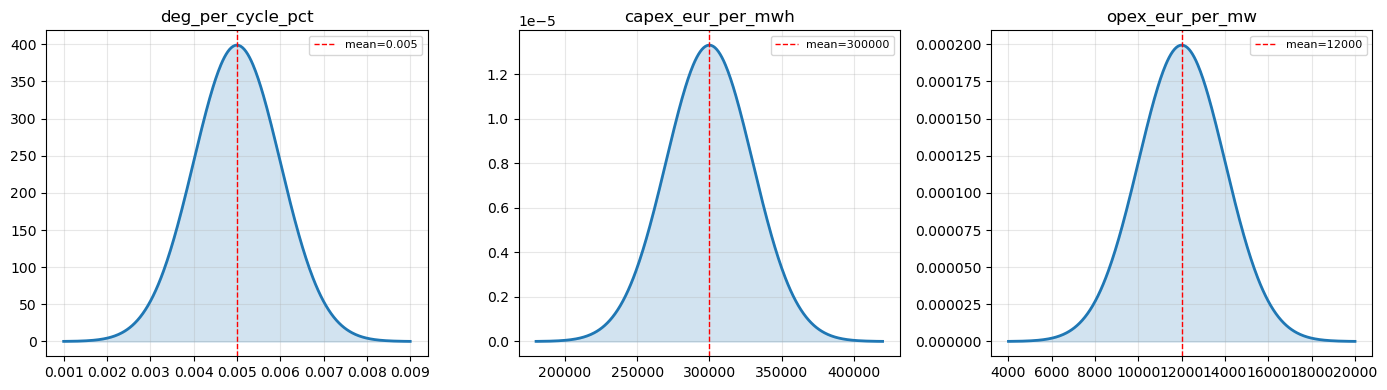

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, p) in zip(axes, STOCHASTIC_INPUTS.items()):
    mean, std, low, high = p["mean"], p["std"], p["low"], p["high"]
    a, b = (low - mean) / std, (high - mean) / std
    x_lo = max(low, mean - 4 * std)
    x_hi = min(high, mean + 4 * std) if np.isfinite(high) else mean + 4 * std
    x = np.linspace(x_lo, x_hi, 400)
    y = truncnorm.pdf(x, a, b, loc=mean, scale=std)
    ax.plot(x, y, color="#1f77b4", lw=2)
    ax.fill_between(x, y, alpha=0.2, color="#1f77b4")
    ax.axvline(mean, color="red", ls="--", lw=1, label=f"mean={mean:g}")
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 2b. Cycles per day (drawn each year)

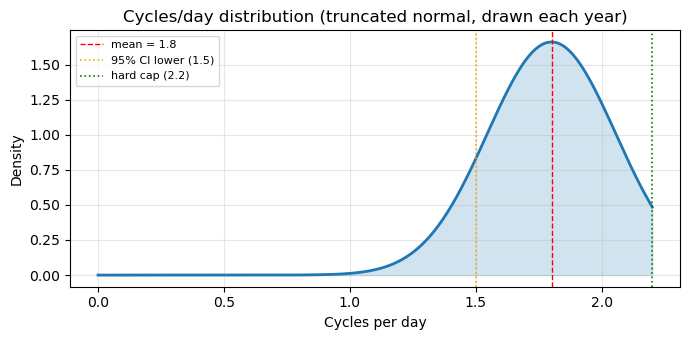

Implied 95% CI (untruncated): [1.30, 2.30]  — upper capped at 2.2


In [8]:
fig, ax = plt.subplots(figsize=(7, 3.5))
_a, _b = (CYCLES_LOW - CYCLES_MEAN) / CYCLES_STD, (CYCLES_HIGH - CYCLES_MEAN) / CYCLES_STD
x_cyc = np.linspace(CYCLES_LOW, CYCLES_HIGH, 400)
y_cyc = truncnorm.pdf(x_cyc, _a, _b, loc=CYCLES_MEAN, scale=CYCLES_STD)
ax.plot(x_cyc, y_cyc, color="#1f77b4", lw=2)
ax.fill_between(x_cyc, y_cyc, alpha=0.2, color="#1f77b4")
ax.axvline(CYCLES_MEAN, color="red",    ls="--", lw=1,   label=f"mean = {CYCLES_MEAN}")
ax.axvline(1.5,         color="orange", ls=":",  lw=1.2, label="95% CI lower (1.5)")
ax.axvline(2.2,         color="green",  ls=":",  lw=1.2, label="hard cap (2.2)")
ax.set_xlabel("Cycles per day")
ax.set_ylabel("Density")
ax.set_title("Cycles/day distribution (truncated normal, drawn each year)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"Implied 95% CI (untruncated): [{CYCLES_MEAN - 1.96*CYCLES_STD:.2f}, "
      f"{CYCLES_MEAN + 1.96*CYCLES_STD:.2f}]  — upper capped at {CYCLES_HIGH}")

### 2c. Declining daily spread curve (EUR/MWh, now → 2050)

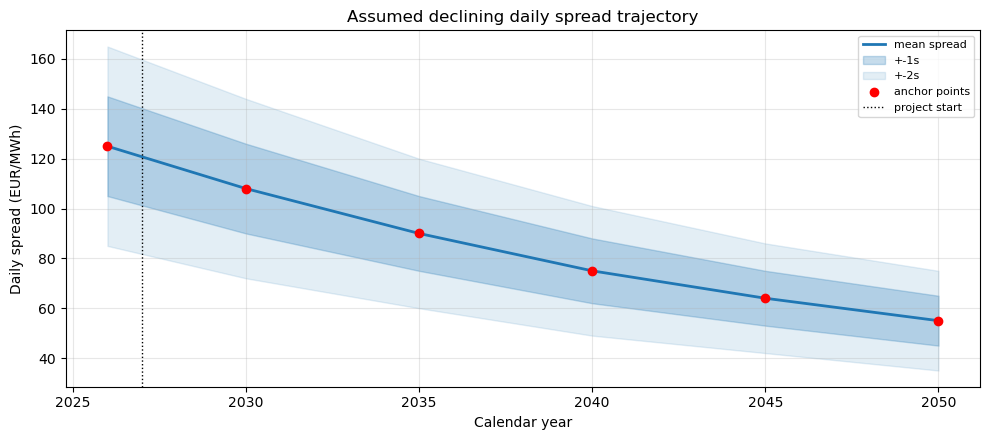

In [9]:
plot_years = np.arange(_anchor_years.min(), _anchor_years.max() + 1)
plot_means = np.array([spread_mean_std(y)[0] for y in plot_years])
plot_stds  = np.array([spread_mean_std(y)[1] for y in plot_years])

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(plot_years, plot_means, color="#1f77b4", lw=2, label="mean spread")
ax.fill_between(plot_years, plot_means - plot_stds, plot_means + plot_stds,
                 alpha=0.25, color="#1f77b4", label="+-1s")
ax.fill_between(plot_years, plot_means - 2*plot_stds, plot_means + 2*plot_stds,
                 alpha=0.12, color="#1f77b4", label="+-2s")
ax.scatter(_anchor_years, _anchor_means, color="red", zorder=5, label="anchor points")
ax.axvline(PROJECT_START_YEAR, color="black", ls=":", lw=1, label="project start")
ax.set_xlabel("Calendar year")
ax.set_ylabel("Daily spread (EUR/MWh)")
ax.set_title("Assumed declining daily spread trajectory")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Monte Carlo simulation engine

**Per-simulation draws** (project-level fixed characteristics): degradation/cycle, CAPEX, OPEX.

**Per-year draws** (inside the loop, capturing dispatch and market variability each year):
- `cycles_per_day` — truncated normal (mean=2, σ=0.255, [0, 2.2])
- `daily_spread` — from the declining EUR/MWh anchor curve

**Revenue and degradation are coupled**: cycles_per_day drives both income *and* how fast SoH
falls, so a high-cycling year earns more but also degrades the asset faster — which reduces
effective MWh in all subsequent years.

In [11]:
MAX_YEARS_SAFETY_CAP = 60  # guard against near-zero degradation draws

def run_simulation(n_sims, mw, mwh, discount_rate, stochastic_inputs, soh_cutoff_pct,
                    cycles_mean, cycles_std, cycles_low, cycles_high,
                    project_start_year, anchor_years, anchor_means, anchor_stds, rng):
    p = stochastic_inputs

    # Draw once per simulation
    deg_cycle = sample_truncnorm(size=n_sims, rng=rng, **p["deg_per_cycle_pct"])
    capex_mwh = sample_truncnorm(size=n_sims, rng=rng, **p["capex_eur_per_mwh"])
    opex_mw   = sample_truncnorm(size=n_sims, rng=rng, **p["opex_eur_per_mw"])

    npvs        = np.empty(n_sims)
    irrs        = np.full(n_sims, np.nan)
    actual_life = np.empty(n_sims)
    all_cashflows = []

    for i in range(n_sims):
        capex     = capex_mwh[i] * mwh
        cashflows = [-capex]
        soh       = 100.0
        year      = 0

        while soh > soh_cutoff_pct and year < MAX_YEARS_SAFETY_CAP:
            year += 1

            # --- Annual draw: cycles per day (dispatch variability) ---
            cycles_day_yr = sample_truncnorm(size=1, rng=rng,
                                              mean=cycles_mean, std=cycles_std,
                                              low=cycles_low, high=cycles_high)[0]
            annual_cycles = cycles_day_yr * 365.0

            # --- Degrade SoH based on actual cycles this year ---
            soh = max(soh - annual_cycles * deg_cycle[i], 0.0)

            # --- Annual draw: daily spread from declining curve ---
            calendar_year = project_start_year + year - 1
            sp_mean = np.interp(calendar_year, anchor_years, anchor_means)
            sp_std  = np.interp(calendar_year, anchor_years, anchor_stds)
            spread  = sample_truncnorm(size=1, rng=rng,
                                        mean=sp_mean, std=sp_std,
                                        low=0, high=np.inf)[0]

            # --- Revenue: spread × effective MWh × cycles × days ---
            mwh_effective = mwh * (soh / 100.0)   # degraded capacity
            revenue = spread * mwh_effective * annual_cycles

            opex = opex_mw[i] * mw
            cashflows.append(revenue - opex)

            if soh <= soh_cutoff_pct:
                break

        actual_life[i] = year
        npvs[i] = npf.npv(discount_rate, cashflows)
        try:
            irrs[i] = npf.irr(cashflows)
        except Exception:
            irrs[i] = np.nan

        if i < 5:
            all_cashflows.append(cashflows)

    return {
        "npv": npvs, "irr": irrs, "life": actual_life,
        "sample_cashflows": all_cashflows,
        "draws": dict(deg_cycle=deg_cycle, capex_mwh=capex_mwh, opex_mw=opex_mw),
    }

results = run_simulation(
    N_SIMULATIONS, MW, MWH, DISCOUNT_RATE, STOCHASTIC_INPUTS, SOH_CUTOFF_PCT,
    CYCLES_MEAN, CYCLES_STD, CYCLES_LOW, CYCLES_HIGH,
    PROJECT_START_YEAR, _anchor_years, _anchor_means, _anchor_stds, rng
)
print(f"Completed {N_SIMULATIONS:,} simulations.")
print(f"Simulations hitting the {MAX_YEARS_SAFETY_CAP}-year safety cap: "
      f"{np.mean(results['life'] >= MAX_YEARS_SAFETY_CAP):.1%}")
print(f"Valid IRR solved for {np.mean(~np.isnan(results['irr'])):.1%} of runs.")

Completed 10,000 simulations.
Simulations hitting the 60-year safety cap: 0.0%
Valid IRR solved for 100.0% of runs.


## 4. Cash flow distribution: NPV and IRR histograms

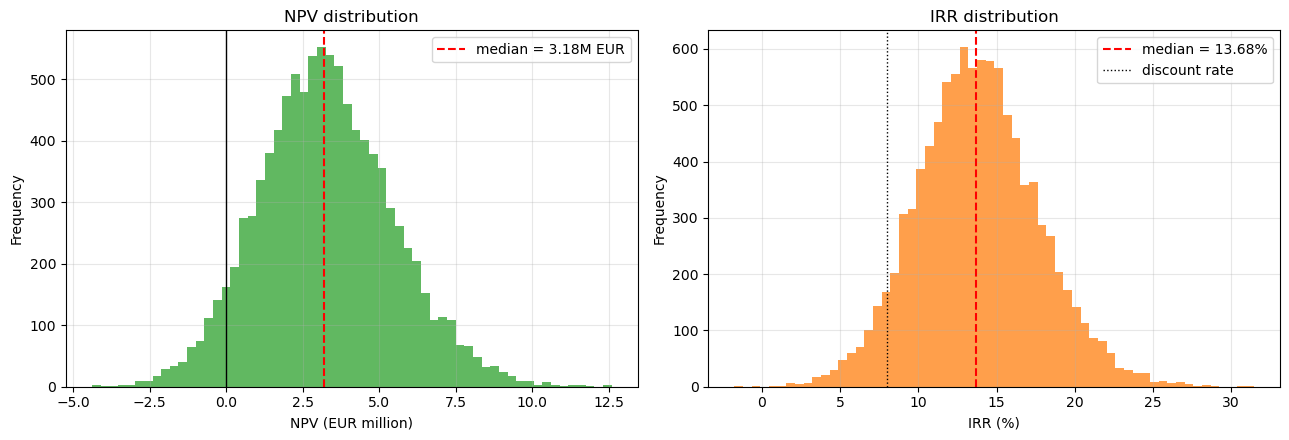

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(results["npv"] / 1e6, bins=60, color="#2ca02c", alpha=0.75)
axes[0].axvline(np.median(results["npv"]) / 1e6, color="red", ls="--",
                 label=f"median = {np.median(results['npv'])/1e6:,.2f}M EUR")
axes[0].axvline(0, color="black", lw=1)
axes[0].set_xlabel("NPV (EUR million)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("NPV distribution")
axes[0].legend()

irr_valid = results["irr"][~np.isnan(results["irr"])]
axes[1].hist(irr_valid * 100, bins=60, color="#ff7f0e", alpha=0.75)
axes[1].axvline(np.median(irr_valid) * 100, color="red", ls="--",
                 label=f"median = {np.median(irr_valid)*100:,.2f}%")
axes[1].axvline(DISCOUNT_RATE * 100, color="black", lw=1, ls=":", label="discount rate")
axes[1].set_xlabel("IRR (%)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("IRR distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Exceedance probability curve

Reads as: *"there is an X% probability that NPV/IRR **exceeds** this value."*
Left = conservative/downside (high exceedance probability = P95); right = optimistic/upside (low
exceedance probability = P5). Vertical markers show P95, P75, P50, P25, P05.
The intersection with the NPV = 0 line gives the probability of a **profitable** project.

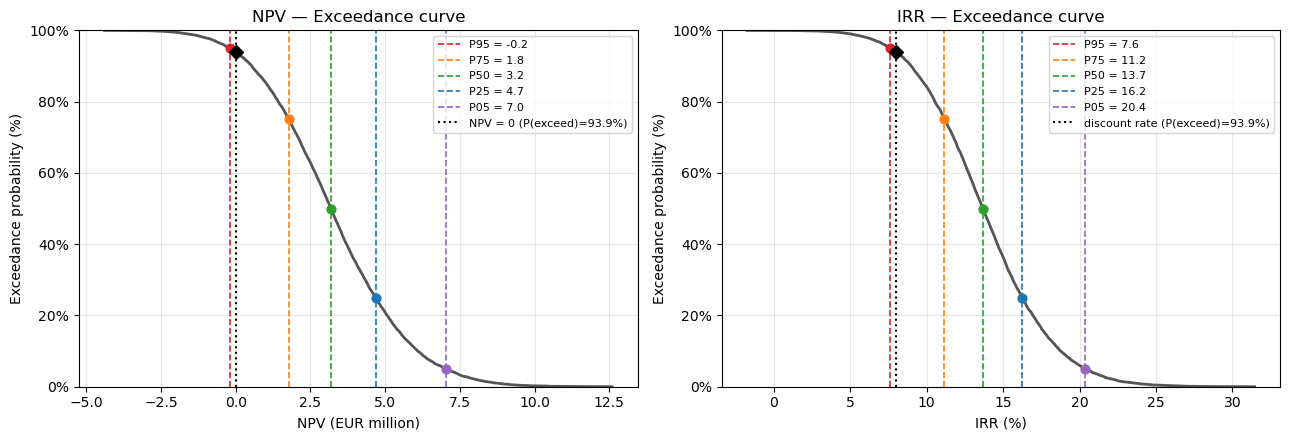

In [13]:
EXCEEDANCE_LEVELS = [95, 75, 50, 25, 5]
LEVEL_COLORS      = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4", "#9467bd"]  # red→purple

def plot_exceedance(ax, data, xlabel, vline=None, vline_label=None):
    data_sorted = np.sort(data)
    # Exceedance = 1 - CDF: probability of exceeding each value
    exceedance = 1 - np.arange(1, len(data_sorted) + 1) / len(data_sorted)
    ax.plot(data_sorted, exceedance * 100, color="#555555", lw=2)

    # P-level markers
    for lvl, col in zip(EXCEEDANCE_LEVELS, LEVEL_COLORS):
        val = np.percentile(data, 100 - lvl)          # exceedance Pxx = stat (100-xx)th pct
        ax.axvline(val, color=col, ls="--", lw=1.2, label=f"P{lvl:02d} = {val:,.1f}")
        ax.scatter([val], [lvl], color=col, zorder=5, s=40)

    if vline is not None:
        prob_exceed = np.mean(data > vline) * 100
        ax.axvline(vline, color="black", lw=1.5, ls=":", label=f"{vline_label} (P(exceed)={prob_exceed:.1f}%)")
        ax.scatter([vline], [prob_exceed], color="black", zorder=6, s=50, marker="D")

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Exceedance probability (%)")
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
    ax.legend(fontsize=8, loc="upper right")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_exceedance(axes[0], results["npv"] / 1e6, "NPV (EUR million)", vline=0, vline_label="NPV = 0")
axes[0].set_title("NPV — Exceedance curve")

plot_exceedance(axes[1], irr_valid * 100, "IRR (%)", vline=DISCOUNT_RATE * 100, vline_label="discount rate")
axes[1].set_title("IRR — Exceedance curve")

plt.tight_layout()
plt.show()

## 6. Summary statistics

**Percentile convention: exceedance probability** — P95 is the conservative/downside value
(only 5% of simulations did worse), P5 is the optimistic/upside value (only 5% of simulations did
better). Table runs P95 → P5, i.e. worst-to-best, left to right within each block.

| Label | Meaning | Statistical percentile |
|---|---|---|
| P95 | Conservative / downside case | 5th |
| P75 | Lower-mid case | 25th |
| P50 | Median | 50th |
| P25 | Upper-mid case | 75th |
| P05 | Optimistic / upside case | 95th |

In [14]:
def exceedance_percentiles(data, levels=(95, 75, 50, 25, 5)):
    """Return a dict of P{level} -> value, using exceedance-probability convention:
    Pxx = the value exceeded with probability xx% = statistical (100 - xx)th percentile.
    Ordered P95 (conservative) -> P05 (optimistic)."""
    data = np.asarray(data)
    return {f"P{lvl:02d}": np.percentile(data, 100 - lvl) for lvl in levels}

def build_summary(data, label):
    base = pd.Series(data).agg(["count", "mean", "std", "min", "max"])
    pcts = pd.Series(exceedance_percentiles(data))
    # P95 (downside) first, P05 (upside) last
    ordered = pd.concat([base[["count", "mean", "std", "min"]],
                          pcts[["P95", "P75", "P50", "P25", "P05"]],
                          base[["max"]]])
    ordered.name = label
    return ordered

summary = pd.concat([
    build_summary(results["npv"], "NPV (EUR)"),
    build_summary(irr_valid * 100, "IRR (%)"),
    build_summary(results["life"], "Project life (yrs)"),
], axis=1)

print(f"P(NPV > 0) [= P05 upside share]: {np.mean(results['npv'] > 0):.1%}")
print(f"P(IRR > discount rate)         : {np.mean(irr_valid > DISCOUNT_RATE):.1%}")
print(f"Simulations with no real IRR solution: {np.mean(np.isnan(results['irr'])):.1%}")
print()
summary.round(2)

P(NPV > 0) [= P05 upside share]: 93.9%
P(IRR > discount rate)         : 93.9%
Simulations with no real IRR solution: 0.0%



,NPV (EUR),IRR (%),Project life (yrs)
count,10000.00,10000.00,10000.00
mean,3263737.34,13.79,13.49
std,2192028.08,3.89,3.02
min,-4391942.10,-1.77,8.00
P95,-206608.58,7.61,10.00
P75,1776503.82,11.16,11.00
P50,3180735.53,13.68,13.00
P25,4680368.08,16.24,15.00
P05,7049308.91,20.39,19.00
max,12592778.33,31.45,39.00


## Notes / next steps

- **Revenue** is driven by `spread × MWh_effective × cycles_per_day × 365`. SoH degradation
  directly reduces `MWh_effective`, creating the correct feedback loop: a high-cycling year earns
  more *and* degrades faster, which compounds the capacity loss in subsequent years.
- **Cycles per day** are drawn each year (year-to-year dispatch variability). If you want to model
  a per-project dispatch strategy instead (e.g. conservative vs aggressive operator), draw cycles
  once per simulation instead of inside the loop.
- **Spread anchors** are placeholders — replace them with your own German DA spread estimates
  (e.g. fitted from your 2026 price/spread analysis). The 2026 starting point (125 EUR/MWh, σ=20)
  is as specified; the trajectory to 2050 is illustrative.
- **Spread** is drawn truncated at zero, so negative spreads are excluded. If you want to model
  occasional negative-spread days reducing annual revenue, a non-zero lower bound (e.g. −10 EUR/MWh)
  would capture that.
- **Operating life** is purely an output — the project runs until SoH hits `SOH_CUTOFF_PCT` (60%).
- **CAPEX/OPEX correlation**: currently independent draws.
- **Tax & financing**: excluded (unlevered, pre-tax) — flag when ready to add.
- **Degradation**: purely cycle-based; calendar/age-based fade not yet layered in.
